🔍 加载 SVM 分类器进行图像分类...


构建训练样本: 100%|██████████| 1250/1250 [22:47<00:00,  1.09s/it]



✅ 开始训练质量预测回归模型...

🎯 模型评估结果：
- PSNR MSE: 21.4285, R2: 0.7525, 95% CI误差: 2.9131 ~ 3.7121
- SSIM MSE: 0.0244, R2: 0.4871, 95% CI误差: 0.1051 ~ 0.1311
- FID  MSE: 14.8696, R2: 0.1383, 95% CI误差: 1.9762 ~ 2.7209


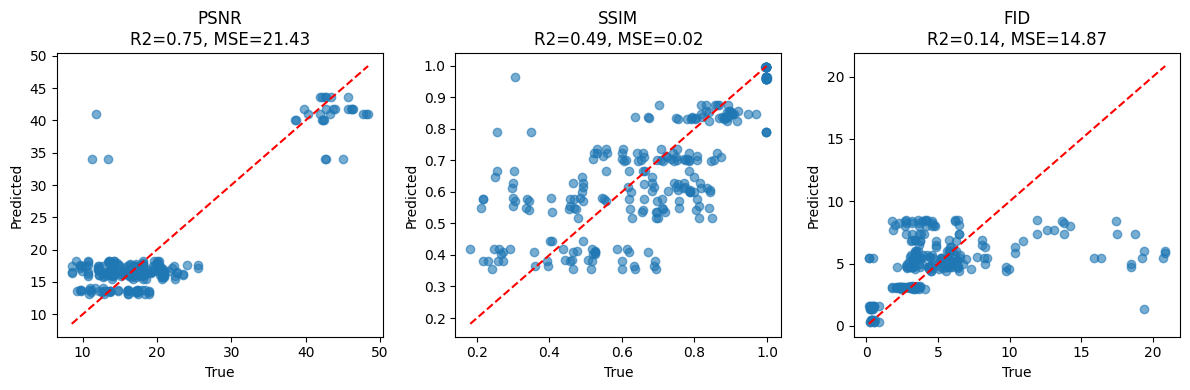


✅ 模型已保存至: C:\Users\charl\OneDrive\Desktop\4442\quality_predictor_by_class_and_method.pkl


In [ ]:

import os
import joblib
import rawpy
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import bootstrap
import matplotlib.pyplot as plt


root = r"C:\Users\charl\OneDrive\Desktop\4442"
csv_path = os.path.join(root, "compression_quality_results.csv")
svm_model_path = os.path.join(root, "svm_model_cnn.pkl")
label_encoder_path = os.path.join(root, "label_encoder_cnn.pkl")
cr3_folder = os.path.join(root, "all")
model_out_path = os.path.join(root, "quality_predictor_by_class_and_method.pkl")



svm = joblib.load(svm_model_path)

import torch
from torchvision.models import inception_v3, Inception_V3_Weights
import torchvision.transforms as transforms
import imageio.v2 as imageio


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = Inception_V3_Weights.DEFAULT
inception = inception_v3(weights=weights, aux_logits=True).to(device)
inception.fc = torch.nn.Identity()
inception.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

def load_cr3_image(path):
    with rawpy.imread(path) as raw:
        return raw.postprocess()

def extract_feature(img_np):
    tensor = transform(img_np).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = inception(tensor)
    return feat.squeeze().cpu().numpy()


def encode_compression(method: str) -> float:
    method = method.lower()
    if method.startswith("jpeg") and method[4:].isdigit():
        return float(method[4:])
    elif method == "jpeg":
        return 100.0
    elif method == "png":
        return 101.0
    elif method == "dng":
        return 102.0
    elif method == "tif":
        return 103.0
    else:
        return -1.0


df = pd.read_csv(csv_path)
features = []
targets = []

for row in tqdm(df.itertuples(), total=len(df), desc="构建训练样本"):
    image_id = row.image_id
    method = row.version
    comp_value = encode_compression(method)
    cr3_path = os.path.join(cr3_folder, f"{image_id}.cr3")
    try:
        img = load_cr3_image(cr3_path)
        feat = extract_feature(img)
        category = svm.predict([feat])[0]
        features.append([category, comp_value])
        targets.append([row.PSNR, row.SSIM, row.FID])
    except Exception as e:
        print(f"[跳过] 图像 {image_id}: {e}")

X = np.array(features)
y = np.array(targets)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("\n✅ 开始训练质量预测回归模型...")
model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='raw_values')


def compute_ci(y_true, y_pred):
    diffs = np.abs(np.array(y_true) - np.array(y_pred))
    ci = bootstrap((diffs,), np.mean, confidence_level=0.95, n_resamples=1000, method='basic')
    return ci.confidence_interval.low, ci.confidence_interval.high

psnr_ci = compute_ci(y_test[:, 0], y_pred[:, 0])
ssim_ci = compute_ci(y_test[:, 1], y_pred[:, 1])
fid_ci  = compute_ci(y_test[:, 2], y_pred[:, 2])

print("\n🎯 模型评估结果：")
print(f"- PSNR MSE: {mse[0]:.4f}, R2: {r2[0]:.4f}, 95% CI误差: {psnr_ci[0]:.4f} ~ {psnr_ci[1]:.4f}")
print(f"- SSIM MSE: {mse[1]:.4f}, R2: {r2[1]:.4f}, 95% CI误差: {ssim_ci[0]:.4f} ~ {ssim_ci[1]:.4f}")
print(f"- FID  MSE: {mse[2]:.4f}, R2: {r2[2]:.4f}, 95% CI误差: {fid_ci[0]:.4f} ~ {fid_ci[1]:.4f}")


plt.figure(figsize=(12, 4))
labels = ['PSNR', 'SSIM', 'FID']
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test[:, i], y_pred[:, i], alpha=0.6)
    plt.plot([y_test[:, i].min(), y_test[:, i].max()], [y_test[:, i].min(), y_test[:, i].max()], 'r--')
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title(f'{labels[i]}\nR2={r2[i]:.2f}, MSE={mse[i]:.2f}')
plt.tight_layout()
plt.show()


joblib.dump(model, model_out_path)
print(f"\n✅ 模型已保存至: {model_out_path}")


In [ ]:

import os
import joblib
import rawpy
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision.models import inception_v3, Inception_V3_Weights


root = r"C:\Users\charl\OneDrive\Desktop\4442"
svm_model_path = os.path.join(root, "svm_model_cnn.pkl")
predictor_path = os.path.join(root, "quality_predictor_by_class_and_method.pkl")


svm = joblib.load(svm_model_path)
predictor = joblib.load(predictor_path)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = Inception_V3_Weights.DEFAULT
inception = inception_v3(weights=weights, aux_logits=True).to(device)
inception.fc = torch.nn.Identity()
inception.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

def load_cr3_image(path):
    import rawpy
    with rawpy.imread(path) as raw:
        return raw.postprocess()

def extract_feature(img_np):
    tensor = transform(img_np).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = inception(tensor)
    return feat.squeeze().cpu().numpy()

def encode_compression(method: str) -> float:
    method = method.lower()
    if method.startswith("jpeg") and method[4:].isdigit():
        return float(method[4:])
    elif method == "jpeg":
        return 100.0
    elif method == "png":
        return 101.0
    elif method == "dng":
        return 102.0
    elif method == "tif":
        return 103.0
    else:
        return -1.0


def predict_quality(cr3_path: str, method_name: str):
    category_names = ["animal", "building", "flight", "mountain", "view"]
    try:
        img = load_cr3_image(cr3_path)
        feat = extract_feature(img)
        category = svm.predict([feat])[0]
        comp_value = encode_compression(method_name)

        input_feat = np.array([[category, comp_value]])
        pred = predictor.predict(input_feat)[0]

        print(f"\n✅ 输入图像: {os.path.basename(cr3_path)}")
        print(f"📦 压缩方式: {method_name} → 编码值: {comp_value}")
        print(f"🔍 分类结果: category{category} ({category_names[category]})")
        print("\n🎯 预测指标:")
        print(f"- PSNR: {pred[0]:.2f}")
        print(f"- SSIM: {pred[1]:.4f}")
        print(f"- FID : {pred[2]:.2f}")
        return pred

    except Exception as e:
        print(f"❌ 预测失败: {e}")
        return None


if __name__ == "__main__":
    test_path = os.path.join(root, "test", "17.cr3")
    test_method = "jpeg66"
    predict_quality(test_path, test_method)



✅ 输入图像: 17.cr3
📦 压缩方式: jpeg66 → 编码值: 66.0
🔍 分类结果: category2 (flight)

🎯 预测指标:
- PSNR: 16.98
- SSIM: 0.8478
- FID : 3.08
